# Milestone 2
- merge each one's dataset
- descriptive statistics
- visualization (put all vis into another notebook)
- pipeline
- regression


# 1. Data sets

In [167]:
import pandas as pd

## YOU NEED TO SPECIFY WHERE THESE DATASETS CAME FROM AND HOW YOU DOWNLOADED

In [168]:
def basic_stats(df):
    countries = list(df['country'].unique())
    n_countries = len(countries) 
    time_series = f"{df.year.min()} ~ {df.year.max()}"
    missing_data_summary = df.drop(['country','year'], axis=1).notna().sum()
    
    return {
        'countries (first 5)': countries[:5],
        'country_count': n_countries,
        'time_series': time_series,
        'observations_bycolumn': missing_data_summary
    }


## 1.1 Agri
- Where is this data set from?

In [169]:
df_agri = pd.read_csv('../data/processed/Agriculture_data.csv')
df_agri = df_agri.rename(columns={'code': 'country'})
df_agri.head(2)

,country,year,FarmCredit,ICTPolicy,ProductionValue,ProcessingValue,Fertilizer
0,BGD,2000,NaN,NaN,583661.0,NaN,158.108
1,BGD,2001,NaN,NaN,590372.0,NaN,174.590


In [170]:
basic_stats(df_agri)

{'countries (first 5)': ['BGD', 'BRN', 'BTN', 'IDN', 'IND'],
 'country_count': 16,
 'time_series': '2000 ~ 2023',
 'observations_bycolumn': FarmCredit          68
 ICTPolicy           34
 ProductionValue     99
 ProcessingValue    111
 Fertilizer          64
 dtype: int64}

## 1.2 Con

In [171]:
df_con = pd.read_csv('../data/processed/control_var.csv')
df_con = df_con.drop(['country'], axis = 'columns').rename(columns={'code': 'country'})
df_con.head(2)

,country,year,"Fertility rate, total (births per woman)","GDP per capita, PPP (constant 2021 international $)","Life expectancy at birth, total (years)","Mortality rate, infant (per 1,000 live births)",Population density (people per sq. km of land area),Population growth (annual %),"Population, total",Poverty headcount ratio at national poverty lines (% of population),Rural population (% of total population),Urban population (% of total population)
0,BGD,1960,6.742,NaN,43.980,178.6,NaN,NaN,51828660.0,NaN,94.865,5.135
1,BGD,1961,6.780,NaN,44.887,173.3,409.544042,2.818718,53310348.0,NaN,94.722,5.278


In [172]:
basic_stats(df_con)

{'countries (first 5)': ['BGD', 'BTN', 'BRN', 'KHM', 'IND'],
 'country_count': 16,
 'time_series': '1960 ~ 2023',
 'observations_bycolumn': Fertility rate, total (births per woman)                               1024
 GDP per capita, PPP (constant 2021 international $)                     543
 Life expectancy at birth, total (years)                                1024
 Mortality rate, infant (per 1,000 live births)                          970
 Population density (people per sq. km of land area)                     992
 Population growth (annual %)                                           1008
 Population, total                                                      1024
 Poverty headcount ratio at national poverty lines (% of population)      89
 Rural population (% of total population)                               1024
 Urban population (% of total population)                               1024
 dtype: int64}

## 1.3 GFI

In [173]:
df_gfi = pd.read_csv('../Data/processed/cleaned_output_2011_2022.csv')
df_gfi = df_gfi.rename(columns={'code': 'country'})
df_gfi.head(2)
basic_stats(df_gfi)

{'countries (first 5)': ['BGD', 'BRN', 'BTN', 'IDN', 'IND'],
 'country_count': 17,
 'time_series': '2011 ~ 2022',
 'observations_bycolumn': Account (% age 15+)                                                                                                              192
 Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)                  192
 Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)          192
 Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)            192
 Account ownership at a financial institution or with a mobile-money-service provider, older adults (% of population ages 25+)    192
                                                                                                                                 ... 
 Used a mobile phone or the internet to send money (% age

In [174]:
basic_stats(df_gfi)

{'countries (first 5)': ['BGD', 'BRN', 'BTN', 'IDN', 'IND'],
 'country_count': 17,
 'time_series': '2011 ~ 2022',
 'observations_bycolumn': Account (% age 15+)                                                                                                              192
 Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)                  192
 Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)          192
 Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)            192
 Account ownership at a financial institution or with a mobile-money-service provider, older adults (% of population ages 25+)    192
                                                                                                                                 ... 
 Used a mobile phone or the internet to send money (% age

## 1.4 Staple

In [175]:
df_staple = pd.read_csv('../Data/processed/StapleFoodStability_adjusted.csv')
df_staple = df_staple.rename(columns={'code': 'country'})
df_staple.head(2)
basic_stats(df_staple)

{'countries (first 5)': ['AFG', 'BGD', 'BTN', 'KHM', 'IND'],
 'country_count': 18,
 'time_series': '2010 ~ 2022',
 'observations_bycolumn': Food supply quantity (kg/capita/yr)_Cereals - Excluding Beer    225
 Food supply quantity (kg/capita/yr)_Starchy Roots               225
 rolling_std                                                     221
 dtype: int64}

In [176]:
basic_stats(df_staple)

{'countries (first 5)': ['AFG', 'BGD', 'BTN', 'KHM', 'IND'],
 'country_count': 18,
 'time_series': '2010 ~ 2022',
 'observations_bycolumn': Food supply quantity (kg/capita/yr)_Cereals - Excluding Beer    225
 Food supply quantity (kg/capita/yr)_Starchy Roots               225
 rolling_std                                                     221
 dtype: int64}

## 1.5 Access

In [178]:
df_access = pd.read_csv('../Data/processed/access_merged.csv')
df_access['year'] = pd.to_datetime(df_access['year']).dt.year
df_access = df_access.rename(columns={'code': 'country'})
df_access.head(2)


,country,year,Rural Access to Electricity(Percent of Population),Mobile Cellular Subscriptions (per 100 people),Fixed Broadband Subsciptions (per 100 people)
0,BGD,2024,NaN,NaN,NaN
1,BGD,2023,99.6,NaN,7.51447


In [179]:
basic_stats(df_access)

{'countries (first 5)': ['BGD', 'BTN', 'IND', 'LKA', 'NPL'],
 'country_count': 16,
 'time_series': '1960 ~ 2024',
 'observations_bycolumn': Rural Access to Electricity(Percent of Population)    446
 Mobile Cellular Subscriptions (per 100 people)        808
 Fixed Broadband Subsciptions (per 100 people)         333
 dtype: int64}

## 1.6 Mobile

In [180]:
df_mobile = pd.read_csv('../Data/processed/mobile_transact.csv')
# Filter for specific countries in South Asia and Southeast Asia
country_list = ['AFG', 'BGD', 'BRN', 'BTN', 'IDN', 'IND', 'IRN', 'KHM', 'LAO',
       'LKA', 'MDV', 'MMR', 'MYS', 'NPL', 'PAK', 'PHL', 'SGP', 'THA',
       'TLS', 'VNM', 'WLD']
df_mobile = df_mobile[df_mobile['code'].isin(country_list)]

df_mobile = df_mobile.rename(columns={'code': 'country'})
df_mobile = df_mobile[['country', 'year', 'mobile_money_transactions']]
df_mobile.head(2)


,country,year,mobile_money_transactions
80,IDN,2016,7.063689e+06
81,IDN,2017,1.237547e+07


In [181]:
basic_stats(df_mobile)

{'countries (first 5)': ['IDN', 'MMR', 'BGD', 'PAK', 'PHL'],
 'country_count': 19,
 'time_series': '2016 ~ 2023',
 'observations_bycolumn': mobile_money_transactions    152
 dtype: int64}

# 2. Merge Datasets

# MAKE SURE TO MERGE ONE BY ONE

In [183]:
import pandas as pd

def merge_and_count(df_1, df_2, how = 'inner'):
    country_col = 'country'
    date_col = 'year'
    rows_df_1, rows_df_2 = len(df_1), len(df_2)
    merged_df = pd.merge(df_1, df_2, how=how, on=[country_col, date_col])

    countries_df_1 = df_1[country_col].unique()
    countries_merged = merged_df[country_col].unique()

    dropped_countries = set(countries_df_1) - set(countries_merged)

    rows_merged = len(merged_df)
    countries_df_1_count, countries_merged_count = (
        len(countries_df_1),
        len(countries_merged)
    )

    print(f"Rows in df_1: {rows_df_1}, Countries in df_1: {countries_df_1_count}")
    print(f"Rows in df_2: {rows_df_2}, Countries in df_2: {countries_merged_count}")
    print(f"Rows in merged DataFrame: {rows_merged}, Countries in merged DataFrame: {countries_merged_count}")
    print(f"Dropped countries from df_1: {list(dropped_countries)}")

    return merged_df

## 2.1 Merge con and agri

In [184]:
df_merge_1 = merge_and_count(
    df_1 = df_con,
    df_2 = df_agri,
    how = 'outer'
)
df_merge_1.head(2)


Rows in df_1: 1024, Countries in df_1: 16
Rows in df_2: 270, Countries in df_2: 16
Rows in merged DataFrame: 1061, Countries in merged DataFrame: 16
Dropped countries from df_1: []


,country,year,"Fertility rate, total (births per woman)","GDP per capita, PPP (constant 2021 international $)","Life expectancy at birth, total (years)","Mortality rate, infant (per 1,000 live births)",Population density (people per sq. km of land area),Population growth (annual %),"Population, total",Poverty headcount ratio at national poverty lines (% of population),Rural population (% of total population),Urban population (% of total population),FarmCredit,ICTPolicy,ProductionValue,ProcessingValue,Fertilizer
0,BGD,1960,6.742,NaN,43.980,178.6,NaN,NaN,51828660.0,NaN,94.865,5.135,NaN,NaN,NaN,NaN,NaN
1,BGD,1961,6.780,NaN,44.887,173.3,409.544042,2.818718,53310348.0,NaN,94.722,5.278,NaN,NaN,NaN,NaN,NaN


## 2.2 Merge df_merge1 and GFI

In [185]:
df_merge_2 = merge_and_count(
    df_1 = df_merge_1,
    df_2 = df_gfi,
    how = 'outer'
)
df_merge_2.head(2)

Rows in df_1: 1061, Countries in df_1: 16
Rows in df_2: 204, Countries in df_2: 17
Rows in merged DataFrame: 1073, Countries in merged DataFrame: 17
Dropped countries from df_1: []


,country,year,"Fertility rate, total (births per woman)","GDP per capita, PPP (constant 2021 international $)","Life expectancy at birth, total (years)","Mortality rate, infant (per 1,000 live births)",Population density (people per sq. km of land area),Population growth (annual %),"Population, total",Poverty headcount ratio at national poverty lines (% of population),...,"Used a mobile phone or the internet to check account balance(% with a financial institution account, age 15+)","Used a mobile phone or the internet to pay bills, female (% age 15+)","Used a mobile phone or the internet to pay bills, male (% age 15+)","Used a mobile phone or the internet to pay bills, rural (% age 15+)","Used a mobile phone or the internet to pay bills, urban (% age 15+)",Used a mobile phone or the internet to send money (% age 15+),"Used a mobile phone or the internet to send money, female (% age 15+)","Used a mobile phone or the internet to send money, male (% age 15+)","Used a mobile phone or the internet to send money, rural (% age 15+)","Used a mobile phone or the internet to send money, urban (% age 15+)"
0,BGD,1960,6.742,NaN,43.980,178.6,NaN,NaN,51828660.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BGD,1961,6.780,NaN,44.887,173.3,409.544042,2.818718,53310348.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.3 Merge df_merge2 and staple

In [186]:
df_merge_3 = merge_and_count(
    df_1 = df_merge_2,
    df_2 = df_staple,
    how = 'outer'
)
df_merge_3.head(2)

Rows in df_1: 1073, Countries in df_1: 17
Rows in df_2: 225, Countries in df_2: 21
Rows in merged DataFrame: 1125, Countries in merged DataFrame: 21
Dropped countries from df_1: []


,country,year,"Fertility rate, total (births per woman)","GDP per capita, PPP (constant 2021 international $)","Life expectancy at birth, total (years)","Mortality rate, infant (per 1,000 live births)",Population density (people per sq. km of land area),Population growth (annual %),"Population, total",Poverty headcount ratio at national poverty lines (% of population),...,"Used a mobile phone or the internet to pay bills, rural (% age 15+)","Used a mobile phone or the internet to pay bills, urban (% age 15+)",Used a mobile phone or the internet to send money (% age 15+),"Used a mobile phone or the internet to send money, female (% age 15+)","Used a mobile phone or the internet to send money, male (% age 15+)","Used a mobile phone or the internet to send money, rural (% age 15+)","Used a mobile phone or the internet to send money, urban (% age 15+)",Food supply quantity (kg/capita/yr)_Cereals - Excluding Beer,Food supply quantity (kg/capita/yr)_Starchy Roots,rolling_std
0,AFG,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202.73,6.69,NaN
1,AFG,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,197.29,5.72,NaN


## 2.4 Merge df_merge3 and access

In [187]:
df_merge_4 = merge_and_count(
    df_1 = df_merge_3,
    df_2 = df_access,
    how = 'outer'
)
df_merge_4.head(2)


Rows in df_1: 1125, Countries in df_1: 21
Rows in df_2: 1040, Countries in df_2: 21
Rows in merged DataFrame: 1141, Countries in merged DataFrame: 21
Dropped countries from df_1: []


,country,year,"Fertility rate, total (births per woman)","GDP per capita, PPP (constant 2021 international $)","Life expectancy at birth, total (years)","Mortality rate, infant (per 1,000 live births)",Population density (people per sq. km of land area),Population growth (annual %),"Population, total",Poverty headcount ratio at national poverty lines (% of population),...,"Used a mobile phone or the internet to send money, female (% age 15+)","Used a mobile phone or the internet to send money, male (% age 15+)","Used a mobile phone or the internet to send money, rural (% age 15+)","Used a mobile phone or the internet to send money, urban (% age 15+)",Food supply quantity (kg/capita/yr)_Cereals - Excluding Beer,Food supply quantity (kg/capita/yr)_Starchy Roots,rolling_std,Rural Access to Electricity(Percent of Population),Mobile Cellular Subscriptions (per 100 people),Fixed Broadband Subsciptions (per 100 people)
0,AFG,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,202.73,6.69,NaN,NaN,NaN,NaN
1,AFG,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,197.29,5.72,NaN,NaN,NaN,NaN


## 2.5 Merge df_merge4 and mobile

In [188]:
df_merge_5 = merge_and_count(
    df_1 = df_merge_4,
    df_2 = df_mobile,
    how = 'outer'
)
df_merge_5.head(2)
df_merge_5.to_csv('../Data/processed/merged_5.csv', index=False)

Rows in df_1: 1141, Countries in df_1: 21
Rows in df_2: 296, Countries in df_2: 21
Rows in merged DataFrame: 1299, Countries in merged DataFrame: 21
Dropped countries from df_1: []


# 3. Descriptive

In [189]:
df_descriptive = df_merge_5.describe(include='all')
df_descriptive.to_csv('../Data/processed/merged_all_descriptive.csv')


## 3.1 Describe ICT Policy or whatever column you want. What does this mean?

- We used "ICT policy" indicator from Worldbank dataset.The G5 Benchmark, developed by the International Telecommunication Union (ITU), is a framework for assessing the evolution of digital regulation worldwide. 
- It measures how countries have moved from traditional, single-sector ICT regulation to collaborative, multi-stakeholder governance (the "fifth generation" or G5). 
- The benchmark uses 70 indicators across four pillars to evaluate regulatory maturity in 193 countries. The 2023 report shows progress globally, with more countries adopting advanced, inclusive regulatory approaches to support digital transformation.
  1.  collaborative governance,
  2.  policy design principles, 
  3.  digital development toolbox, 
  4.  digital economy policy agenda

(reference) https://digitalregulation.org/wp-content/uploads/D-PREF-BB-2023-01-PDF-E.pdf 

In [190]:
print(df_descriptive['ICTPolicy'])

count     63.000000
unique          NaN
top             NaN
freq            NaN
mean      12.433867
std        5.501345
min        3.703700
25%        7.716050
50%       11.111100
75%       18.827200
max       21.296300
Name: ICTPolicy, dtype: float64


## 3.2 Outcome variables

as a preliminary assessment, 6 variables were selectd 
1) (<u>financial access</u>) Financial institution account, female (% age 15+)
2) (<u>e-commerce</u>) Made a digital in-store merchant payment: using a mobile phone (% age 15+)
3) (<u>mobile transaction</u>) Use a mobile phone or the internet to make payments, buy things, or to send or receive money using a financial institution account (% age 15+)
4) (<u>saving</u>) Saved at a financial institution or using a mobile money account (% age 15+)
5) (<u>Food productivity</u>) Food supply quantity (kg/capita/yr)_Cereals - Excluding Beer
6) (<u>Resilience on food production</u>) rolling_std (let's change variable name as "food supply stability")



In [191]:
print(df_descriptive[['Financial institution account, female (% age 15+)', 'Made a digital in-store merchant payment: using a mobile phone (% age 15+)', 'Saved at a financial institution or using a mobile money account (% age 15+)', 'Store money using a financial institution or a mobile money account (% age 15+)', 'Use a mobile phone or the internet to make payments, buy things, or to send or receive money using a financial institution account (% age 15+)', 'Food supply quantity (kg/capita/yr)_Cereals - Excluding Beer', 'rolling_std']])

        Financial institution account, female (% age 15+)  \
count                                          321.000000   
unique                                                NaN   
top                                                   NaN   
freq                                                  NaN   
mean                                            47.764553   
std                                             26.232088   
min                                              2.950000   
25%                                             28.017500   
50%                                             37.850000   
75%                                             76.640000   
max                                             98.210000   

        Made a digital in-store merchant payment: using a mobile phone (% age 15+)  \
count                                          302.000000                            
unique                                                NaN                            
top      

# ........ below this, i have not done ......

## 3.3 Control variables

# 4. Graph

<AxesSubplot:xlabel='ICTPolicy', ylabel='GDP per capita, PPP (constant 2021 international $)'>

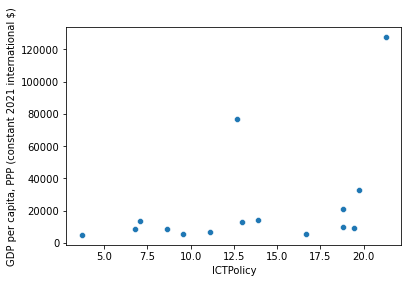

In [63]:
import seaborn as sns
sns.scatterplot(
    data = df_des.query("year == 2023"),
    y = 'GDP per capita, PPP (constant 2021 international $)',
    x = 'ICTPolicy'
)

# 5. Regression

## 5.1 Transform

In [65]:
df_feat = df_des.query("year == 2023")[['GDP per capita, PPP (constant 2021 international $)', 'ICTPolicy']]
df_feat.head(2)

,,"GDP per capita, PPP (constant 2021 international $)",ICTPolicy
country,year,,
BGD,2023,8242.39799,6.79012
BTN,2023,NaN,8.95062


In [67]:
import numpy as np
df_feat = df_feat.assign(
    gdp_log = df_feat['GDP per capita, PPP (constant 2021 international $)'].apply(np.log),
    ict_log = df_feat['ICTPolicy'].apply(np.log)
)
df_feat.head(2)

,,"GDP per capita, PPP (constant 2021 international $)",ICTPolicy,gdp_log,ict_log
country,year,,,,
BGD,2023,8242.39799,6.79012,9.017047,1.915469
BTN,2023,NaN,8.95062,NaN,2.191723


## 5.2 Regression

In [74]:
import statsmodels.api as sm


def regression(df, x, y):
    cols = x + [y]
    data = df[cols].dropna()
    X = data[x]
    X = sm.add_constant(X) # Capital X for convention
    Y = data[y] # Capital Y for convention

    # Create and fit the OLS model
    model = sm.OLS(Y, X)
    results = model.fit()

    return results.summary()


regression(
    df=df_feat,
    x=['ICTPolicy'],
    y='gdp_log'
)



/Users/corybaird/opt/anaconda3/lib/python3.9/site-packages/scipy/stats/stats.py:1541: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                gdp_log   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                     4.578
Date:                Sun, 25 May 2025   Prob (F-statistic):             0.0519
Time:                        14:25:11   Log-Likelihood:                -17.943
No. Observations:                  15   AIC:                             39.89
Df Residuals:                      13   BIC:                             41.30
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.3261      0.599     13.900      0.000       7.032       9.620
ICTPolicy      0.0887      0.041      2.140      0.052      -0.001       0.178
==============================================================================
Omnibus:                        3.353   Durbin-Watson:                   2.063
Prob(Omnibus):                  0.187   Jarque-Bera (JB):                1.709
Skew:                           0.821   Prob(JB):                        0.425
Kurtosis:                       3.197   Cond. No.                         39.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""